In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from config import Config

In [2]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 

image_size = 224

from plant_tokenizer import PAD_token

transform = transforms.Compose([
                        transforms.ToTensor(),
                        # transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        ])

import pickle
# Check if the .plk file exists
dataset_dir = "../data/generated_dataset_Sep22_black"
saved_train_dataset_name = os.path.join(dataset_dir,"train_dataset.pkl")
saved_val_dataset_name = os.path.join(dataset_dir,"val_dataset.pkl")
if os.path.exists(saved_train_dataset_name) and False:
    if os.path.exists(saved_train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(saved_train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(saved_val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    preload = False
    process_leaf = True
    train_dataset = PlantDataset(dataset_dir, plot=["000", "001", "002",], 
                                 stages=["003"],
                                 transform=transform, load_depth=False, preload=preload,
                                 process_leaf=process_leaf,
                                 image_size=image_size) 
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset(dataset_dir, plot=["003"], transform=transform, load_depth=False, preload=preload,
                               process_leaf=process_leaf,
                               image_size=image_size)

    if preload:
        with open(saved_train_dataset_name, "wb") as f:
            pickle.dump(train_dataset, f)
        with open(saved_val_dataset_name, "wb") as f:
            pickle.dump(val_dataset, f)

Total 1159 images and plant strings loaded
Total 1585 images and plant strings loaded


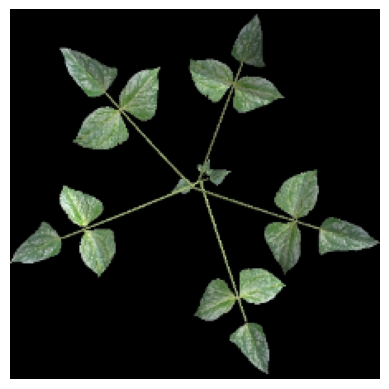

In [3]:
import cv2
img, target, depth = train_dataset[0]


rgb = img[:3]
# Normalize the RGB image to 0-255
rgb = cv2.normalize(rgb.permute(1,2,0).numpy(), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

depth = img[3:]



import matplotlib.pyplot as plt
plt.imshow(rgb)
# Axes are not needed
plt.axis('off')
plt.show()
# plt.imshow(depth[0])
# plt.axis('off')
# plt.show()


In [4]:
from models.plightning import SimpleRegressionTest
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleRegressionTest.load_from_checkpoint("../log/20241008_RGBD_Transformer_MaxPool/version_0/checkpoints/best_epoch=99.ckpt")
model = model.to(device)
model.eval()
# model.freeze()

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


SimpleRegressionTest(
  (depth_est_model): DepthAnythingForDepthEstimation(
    (backbone): Dinov2Backbone(
      (embeddings): Dinov2Embeddings(
        (patch_embeddings): Dinov2PatchEmbeddings(
          (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): Dinov2Encoder(
        (layer): ModuleList(
          (0-11): 12 x Dinov2Layer(
            (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
            (attention): Dinov2Attention(
              (attention): Dinov2SelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): Dinov2SelfOutput(
                (dense): Linear(in_features=384, 

In [5]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define batch size
batch_size = 32

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

# Initialize lists to store predictions and targets
first_vec_pred = []
first_vec_target = []

# Iterate over the DataLoader
for batch in tqdm(train_dataloader):
    imgs, targets, _ = batch
    imgs = imgs.to(device)
    
    with torch.no_grad():
        preds = model(imgs)
    
    # Append predictions and targets
    first_vec_pred.extend(preds.cpu().numpy())
    first_vec_target.extend(targets[:, 1, 1:7].cpu().numpy())

# Convert lists to numpy arrays if needed
first_vec_pred = np.array(first_vec_pred)
first_vec_target = np.array(first_vec_target)



100%|██████████| 37/37 [00:49<00:00,  1.35s/it]


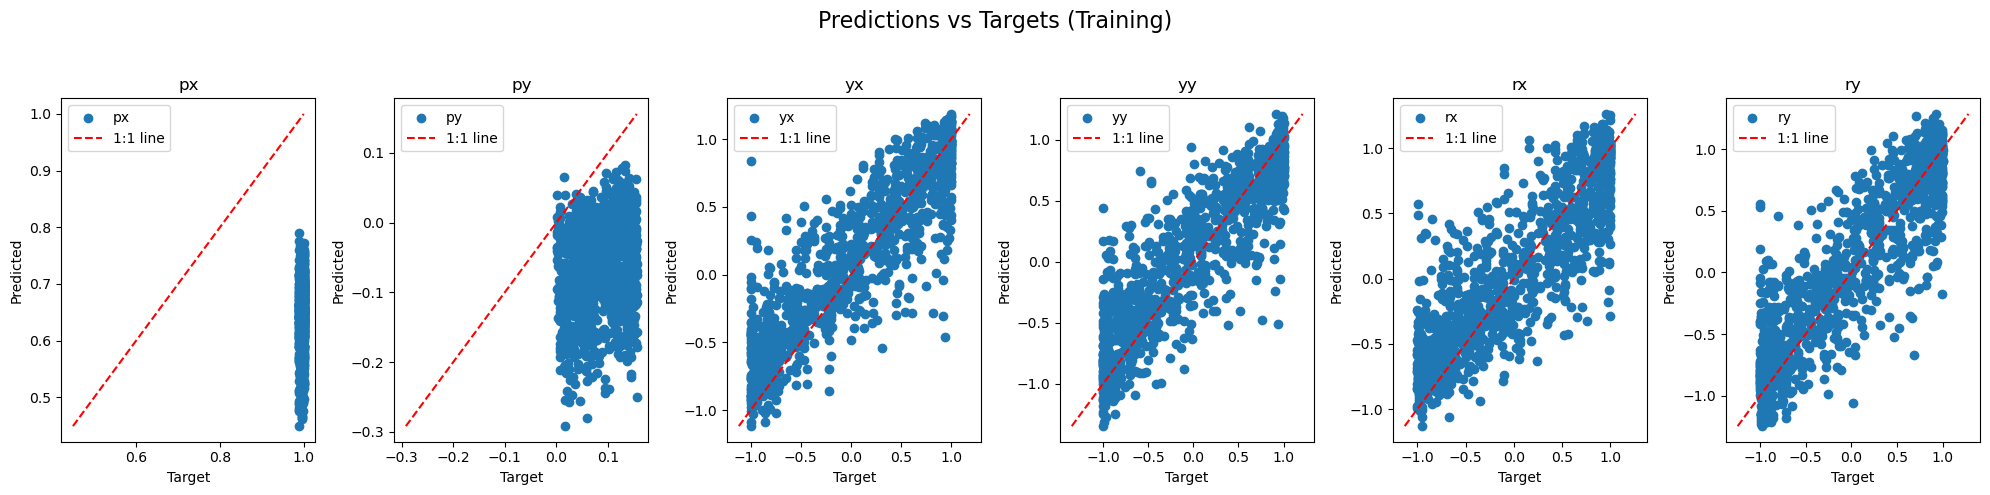

In [6]:
# Plot the predictions and targets
import matplotlib.pyplot as plt
import numpy as np

def plot_subplot(ax, target, pred, index, label):
    min_val = min(np.min(target[:, index]), np.min(pred[:, index]))
    max_val = max(np.max(target[:, index]), np.max(pred[:, index]))
    ax.scatter(target[:, index], pred[:, index], label=label)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
    ax.legend()
    ax.set_title(label)
    ax.set_ylabel("Predicted")
    ax.set_xlabel("Target")

# Create a 1x4 subplot
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# Plot each subplot
plot_subplot(axes[0], first_vec_target, first_vec_pred, 0, "px")
plot_subplot(axes[1], first_vec_target, first_vec_pred, 1, "py")
plot_subplot(axes[2], first_vec_target, first_vec_pred, 2, "yx")
plot_subplot(axes[3], first_vec_target, first_vec_pred, 3, "yy")
plot_subplot(axes[4], first_vec_target, first_vec_pred, 4, "rx")
plot_subplot(axes[5], first_vec_target, first_vec_pred, 5, "ry")

# Add a figure title
fig.suptitle("Predictions vs Targets (Training)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

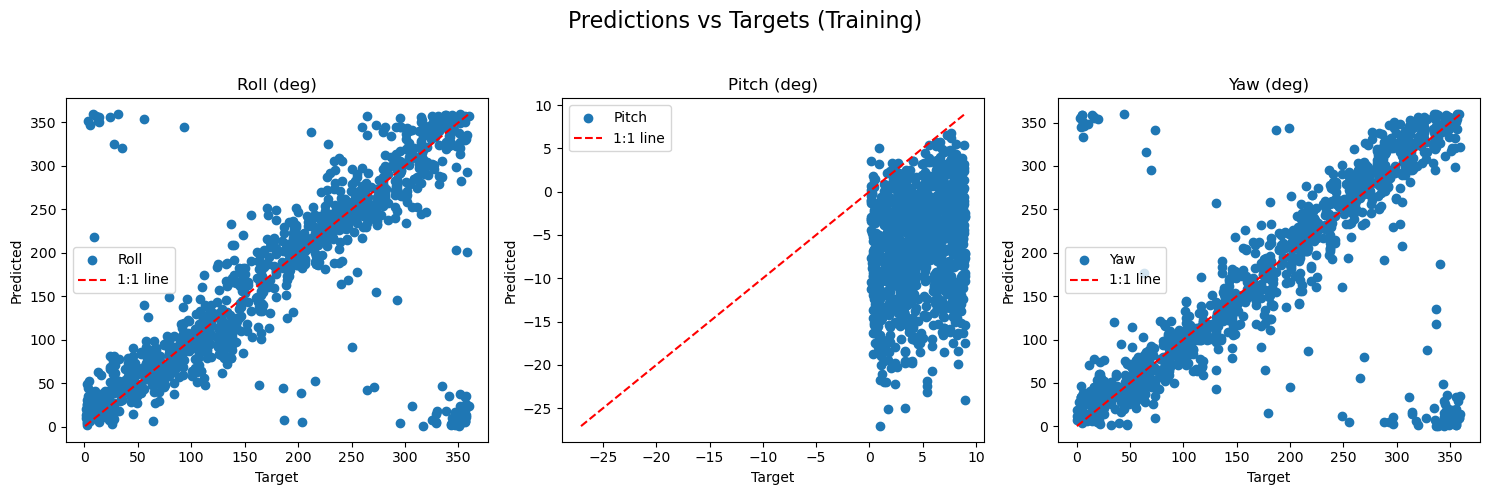

In [7]:
from utils import quaternion_to_euler, coordinates_to_angle
import matplotlib.pyplot as plt
import numpy as np

# Convert quaternions to Euler angles
first_vec_target_euler = np.array([(coordinates_to_angle(x=q[0],y=q[1],angle_max=180), # pitch is in the range of -180 to 180
                                    coordinates_to_angle(x=q[2],y=q[3]),
                                    coordinates_to_angle(x=q[4],y=q[5])) for q in first_vec_target])
first_vec_pred_euler = np.array([(coordinates_to_angle(x=q[0],y=q[1],angle_max=180), # pitch is in the range of -180 to 180
                                    coordinates_to_angle(x=q[2],y=q[3]),
                                    coordinates_to_angle(x=q[4],y=q[5])) for q in first_vec_pred])

def plot_subplot(ax, target, pred, index, label):
    min_val = min(np.min(target[:, index]), np.min(pred[:, index]))
    max_val = max(np.max(target[:, index]), np.max(pred[:, index]))
    ax.scatter(target[:, index], pred[:, index], label=label)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
    ax.legend()
    ax.set_title(f"{label} (deg)")
    ax.set_ylabel("Predicted")
    ax.set_xlabel("Target")

# Create a 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each subplot
plot_subplot(axes[0], first_vec_target_euler, first_vec_pred_euler, 2, "Roll")
plot_subplot(axes[1], first_vec_target_euler, first_vec_pred_euler, 0, "Pitch")
plot_subplot(axes[2], first_vec_target_euler, first_vec_pred_euler, 1, "Yaw")

# Add a figure title
fig.suptitle("Predictions vs Targets (Training)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [8]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define batch size
batch_size = 32

test_dataset = PlantDataset(dataset_dir, plot=["004"], 
                            stages=["003"],
                            transform=transform, load_depth=False, preload=preload,
                               process_leaf=process_leaf,
                               image_size=image_size)
# Create DataLoader
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

# Initialize lists to store predictions and targets
first_vec_pred = []
first_vec_target = []

# Iterate over the DataLoader
for batch in tqdm(test_dataloader):
    imgs, targets, _ = batch
    imgs = imgs.to(device)
    
    with torch.no_grad():
        preds = model(imgs)
    
    # Append predictions and targets
    first_vec_pred.extend(preds.cpu().numpy())
    first_vec_target.extend(targets[:, 1, 1:7].cpu().numpy())

# Convert lists to numpy arrays if needed
first_vec_pred = np.array(first_vec_pred)
first_vec_target = np.array(first_vec_target)




Total 368 images and plant strings loaded


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:17<00:00,  1.45s/it]


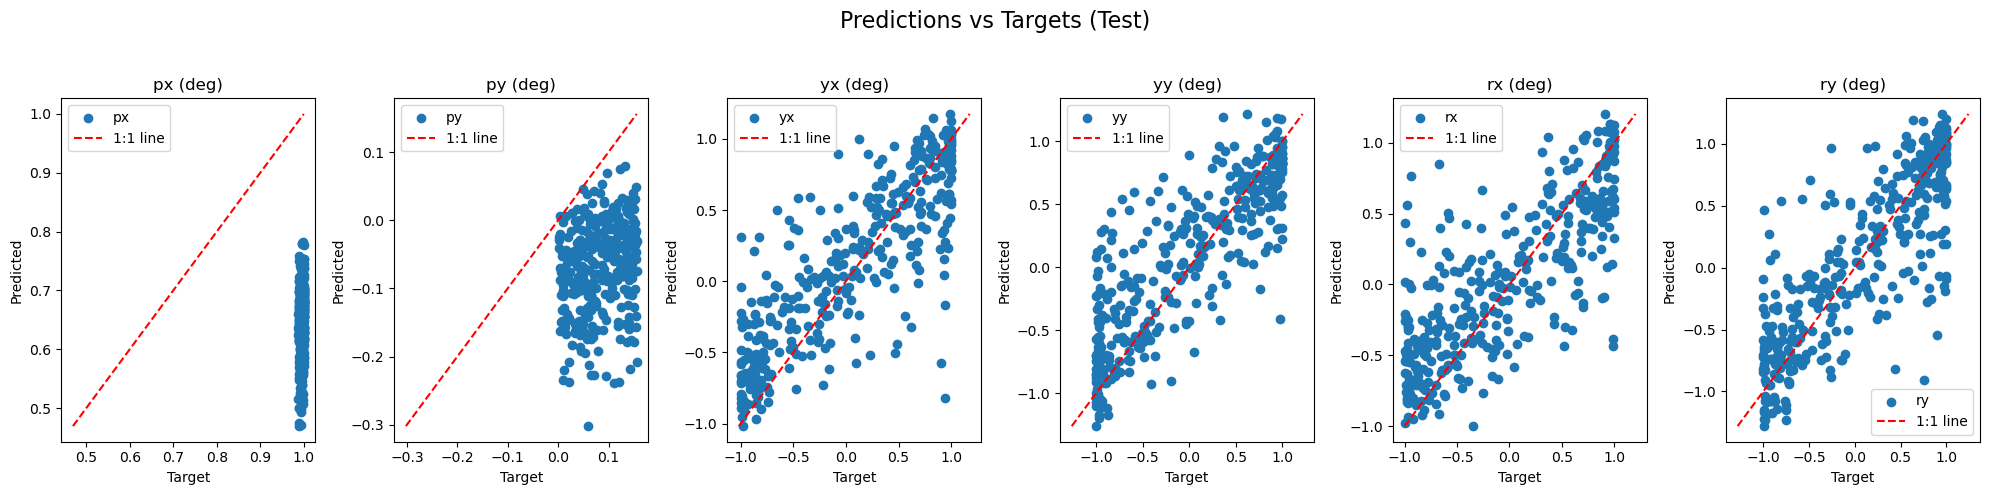

In [9]:
# Create a 1x4 subplot
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# Plot each subplot
plot_subplot(axes[0], first_vec_target, first_vec_pred, 0, "px")
plot_subplot(axes[1], first_vec_target, first_vec_pred, 1, "py")
plot_subplot(axes[2], first_vec_target, first_vec_pred, 2, "yx")
plot_subplot(axes[3], first_vec_target, first_vec_pred, 3, "yy")
plot_subplot(axes[4], first_vec_target, first_vec_pred, 4, "rx")
plot_subplot(axes[5], first_vec_target, first_vec_pred, 5, "ry")

# Add a figure title
fig.suptitle("Predictions vs Targets (Test)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

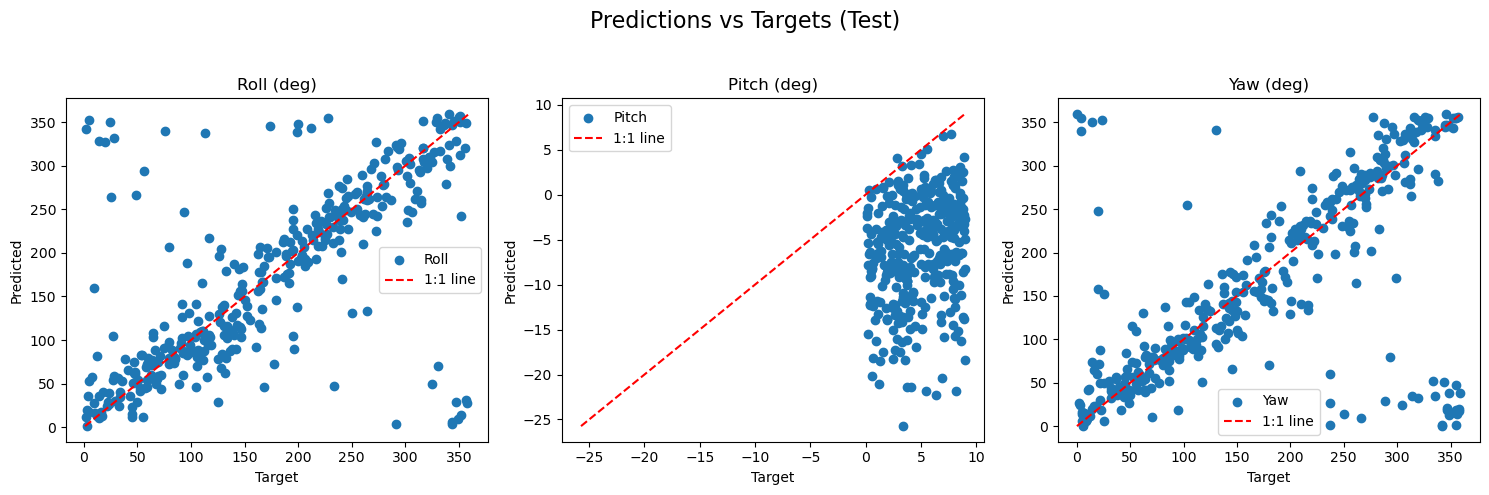

In [10]:
from utils import quaternion_to_euler
import matplotlib.pyplot as plt
import numpy as np

# Convert quaternions to Euler angles
first_vec_target_euler = np.array([(coordinates_to_angle(x=q[0],y=q[1],angle_max=180), # pitch is in the range of -180 to 180
                                    coordinates_to_angle(x=q[2],y=q[3]),
                                    coordinates_to_angle(x=q[4],y=q[5])) for q in first_vec_target])
first_vec_pred_euler = np.array([(coordinates_to_angle(x=q[0],y=q[1],angle_max=180), # pitch is in the range of -180 to 180
                                    coordinates_to_angle(x=q[2],y=q[3]),
                                    coordinates_to_angle(x=q[4],y=q[5])) for q in first_vec_pred])

def plot_subplot(ax, target, pred, index, label):
    min_val = min(np.min(target[:, index]), np.min(pred[:, index]))
    max_val = max(np.max(target[:, index]), np.max(pred[:, index]))
    ax.scatter(target[:, index], pred[:, index], label=label)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 line")
    ax.legend()
    ax.set_title(f"{label} (deg)")
    ax.set_ylabel("Predicted")
    ax.set_xlabel("Target")

# Create a 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each subplot
plot_subplot(axes[1], first_vec_target_euler, first_vec_pred_euler, 0, "Pitch")
plot_subplot(axes[2], first_vec_target_euler, first_vec_pred_euler, 1, "Yaw")
plot_subplot(axes[0], first_vec_target_euler, first_vec_pred_euler, 2, "Roll")

# Add a figure title
fig.suptitle("Predictions vs Targets (Test)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [26]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import params_SOS_token_padded, SOS_token, EOS_token
from plant_tokenizer import token2vec_new as token2vec
from plant_tokenizer import vec2token_new as vec2token
from plant_tokenizer import randomize_plant_vec_params
from models.model import get_tgt_mask
from plant_dataset import collate_fn, PlantDataset
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from utils import coordinates_to_angle, angle_to_coordinates
import copy

# Initialize the model
p2m = plantstring2model(program_path="PlantString2Model/build", program_name="PlantString2Model", display=":11.0", height=1.0, background_path="assets/black.png")

# Define stages and dataset
stages = ["003", "010", "016", "023"]
test_dataset = PlantDataset("../data/generated_dataset_Sep22_black", plot=["004"], stages=stages[0],
                            transform=transform, load_depth=False, preload=False, process_leaf=True, image_size=image_size)
gen_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

# Prepare the figure
fig, axes = plt.subplots(3, 5, figsize=(20, 8))

def process_image(image, device):
    image_vis = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    return img.astype(np.uint8)

def calculate_error(plant_vec_predicted, plant_vec):
    plant_vec_predicted_np = np.array(plant_vec_predicted[0])
    plant_vec_np = np.array(plant_vec[0])
    return np.abs(plant_vec_predicted_np - plant_vec_np)

def save_plant_string(plant_vec, idx, suffix=""):
    plant_string = vec2string([plant_vec])
    plant_string_file_name = f"temp/plant_string_{suffix}_{idx}.txt"
    with open(plant_string_file_name, "w") as f:
        f.write(plant_string)
    return plant_string_file_name

def generate_image(p2m, plant_string_file_name, idx, suffix=""):
    p2m.run(in_plantstring_path=os.path.abspath(plant_string_file_name), output_path=os.path.abspath(f"output_{suffix}_{idx}"))
    return f"output_{suffix}_{idx}/plant_string_{suffix}_{idx}_top.jpeg"

def display_image(ax, img, title):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
# Process and display 10 images
for idx, (image, out, lengths) in enumerate(test_dataset):
    plant_vec = test_dataset.getitem(idx)[1]
    if idx >= 5:
        break

    if image.dim() == 3:
        image = image.unsqueeze(0)
    image = image.to(device)
    result = model(image).squeeze(0).tolist()

    plant_vec_predicted = copy.deepcopy(plant_vec)
    plant_vec_predicted[0][2] = coordinates_to_angle(result[0], result[1], angle_max=180)
    plant_vec_predicted[0][3] = coordinates_to_angle(result[2], result[3])
    plant_vec_predicted[0][4] = coordinates_to_angle(result[4], result[5])

    error = calculate_error(plant_vec_predicted, plant_vec)
    print(f"Error: {error}")

    plant_string_file_name = save_plant_string(plant_vec_predicted, idx)
    generated_image_path = generate_image(p2m, plant_string_file_name, idx)

    img = cv2.imread(generated_image_path)
    leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=True, thr=0.2)
    img = cv2.normalize(leaf_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    img = cv2.resize(leaf_img, (image_size, image_size))

    row, col = divmod(idx, 5)
    image_vis = process_image(image, device)
    axes[row, col].imshow(image_vis[:, :, 0:3])
    axes[row, col].set_title(f"Input Image {idx + 1}")
    axes[row, col].axis('off')

    display_image(axes[row + 1, col], img, f"Output Model {idx + 1}")

    # Add randomized plant vector
    plant_vec_random = randomize_plant_vec_params(copy.deepcopy(plant_vec_predicted))
    plant_string_file_name_random = save_plant_string(plant_vec_random, idx, suffix="random")
    generated_image_path_random = generate_image(p2m, plant_string_file_name_random, idx, suffix="random")

    img_random = cv2.imread(generated_image_path_random)
    leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img_random, sqaure_crop=True, thr=0.2)
    img_random = cv2.normalize(leaf_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    img_random = cv2.resize(leaf_img, (image_size, image_size))

    display_image(axes[row + 2, col], img_random, f"Output Random {idx + 1}")

plt.tight_layout()
plt.show()

ImportError: cannot import name 'randomize_plant_vec_params' from 'plant_tokenizer' (/home/lion397/codes/Image2PlantArchitecture/src/plant_tokenizer.py)